# Notebook 01 — Setup repo & EDA

**Projet** : Scoring defaut de credit + POC GenAI — Datagong  
**Objectif** : Comprendre le dataset (qualite, distributions, relations avec la cible) et figer le protocole d'evaluation.

---

**Plan du notebook**
1. Imports et configuration
2. Chargement des donnees
3. Dictionnaire de donnees
4. Controle qualite
5. Exploration de la cible
6. Protocole d'evaluation

## 1. Imports et configuration

On ajoute `src/` au path Python pour pouvoir importer `config` et `data_prep`.

In [17]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style graphiques
sns.set_theme(style="whitegrid", palette="muted")

print("Imports OK")

Imports OK


## 2. Chargement des donnees

On utilise `load_data()` depuis `src/data_prep.py`.  
Cette fonction charge le CSV et supprime immediatement `predicted_default_payment_next_month` (leakage).

In [18]:

url = "./../data/raw/Credit_card_default.csv"
print(f"URL du fichier csv: {url}")
df= pd.read_csv(url)
# - Leak and Drop de la colonne "predicted_default_payment_next_month"
df_leak = df["predicted_default_payment_next_month"].copy()
df = df.drop(columns=["predicted_default_payment_next_month"])
# - Affiche la forme du DataFrame (nombre de lignes et colonnes)
print(f"Dimensions du dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes")
# - Affiche les 5 premieres lignes avec .head()
display(df.head())


URL du fichier csv: ./../data/raw/Credit_card_default.csv
Dimensions du dataset : 2965 lignes x 25 colonnes


,id,limit_balance,sex,education_level,marital_status,age,pay_0,pay_2,pay_3,pay_4,...,bill_amt_4,bill_amt_5,bill_amt_6,pay_amt_1,pay_amt_2,pay_amt_3,pay_amt_4,pay_amt_5,pay_amt_6,default_payment_next_month
0,27502.0,80000.0,1,6,1,54.0,0.0,0.0,0.0,0.0,...,29296.0,26210.0,17643.0,2545.0,2208.0,1336.0,2232.0,542.0,348.0,1
1,26879.0,200000.0,1,4,1,49.0,0.0,0.0,0.0,0.0,...,50146.0,50235.0,48984.0,1689.0,2164.0,2500.0,3480.0,2500.0,3000.0,0
2,18340.0,20000.0,2,6,2,22.0,0.0,0.0,0.0,0.0,...,1434.0,500.0,0.0,4641.0,1019.0,900.0,0.0,1500.0,0.0,1
3,13692.0,260000.0,2,4,2,33.0,0.0,0.0,0.0,0.0,...,27821.0,30767.0,29890.0,5000.0,5000.0,1137.0,5000.0,1085.0,5000.0,0
4,20405.0,150000.0,1,4,2,32.0,0.0,0.0,0.0,-1.0,...,150464.0,143375.0,146411.0,4019.0,146896.0,157436.0,4600.0,4709.0,5600.0,0


## 3. Dictionnaire de donnees

Produis un tableau avec pour chaque colonne : son nom, son type pandas, une description metier courte, et un exemple de valeur.

**Aide** : les types sont dans `df.dtypes`, les exemples dans `df.iloc[0]`.

In [24]:

# Construis un dictionnaire Python avec les cles :
# "Type", "Description", "Exemple"
dict_donnees = {
    "Definition": [
        "Identifiant client",
        "Plafond de credit accorde (NT$)",
        "Sexe (1=homme, 2=femme)",
        "Niveau d'education (1=3e cycle, 2=universite, 3=lycee, 4=autres)",
        "Statut marital (1=marie, 2=celibataire, 3=autres)",
        "Age du client (annees)",
        "Statut remboursement mois -1",
        "Statut remboursement mois -2",
        "Statut remboursement mois -3",
        "Statut remboursement mois -4",
        "Statut remboursement mois -5",
        "Statut remboursement mois -6",
        "Montant releve mois -1 (NT$)",
        "Montant releve mois -2 (NT$)",
        "Montant releve mois -3 (NT$)",
        "Montant releve mois -4 (NT$)",
        "Montant releve mois -5 (NT$)",
        "Montant releve mois -6 (NT$)",
        "Montant paye mois -1 (NT$)",
        "Montant paye mois -2 (NT$)",
        "Montant paye mois -3 (NT$)",
        "Montant paye mois -4 (NT$)",
        "Montant paye mois -5 (NT$)",
        "Montant paye mois -6 (NT$)",
        "Defaut de paiement le mois suivant (0=non, 1=oui) — CIBLE",
    ],
    "Type":    [str(t) for t in df.dtypes],
    "Exemple": [df[col].iloc[0] for col in df.columns],
}

df_dict= pd.DataFrame(dict_donnees, index=df.columns)
display(df_dict)


,Definition,Type,Exemple
id,Identifiant client,float64,27502.0
limit_balance,Plafond de credit accorde (NT$),float64,80000.0
sex,"Sexe (1=homme, 2=femme)",int64,1.0
education_level,"Niveau d'education (1=3e cycle, 2=universite, ...",int64,6.0
marital_status,"Statut marital (1=marie, 2=celibataire, 3=autres)",int64,1.0
age,Age du client (annees),float64,54.0
pay_0,Statut remboursement mois -1,float64,0.0
pay_2,Statut remboursement mois -2,float64,0.0
pay_3,Statut remboursement mois -3,float64,0.0
pay_4,Statut remboursement mois -4,float64,0.0


## 4. Controle qualite

### 4.1 Valeurs manquantes

In [ ]:
# Nombre et pourcentage de valeurs manquantes par colonne
manquants = df.isnull().sum()
manquants_pct = (manquants / len(df) * 100).round(2)

df_manquants = pd.DataFrame({
    "Nb manquants": manquants,
    "% manquants":  manquants_pct,
}).query("`Nb manquants` > 0")

if df_manquants.empty:
    print("Aucune valeur manquante.")
else:
    display(df_manquants)




Aucune valeur manquante.
<class 'pandas.DataFrame'>
RangeIndex: 2965 entries, 0 to 2964
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          2965 non-null   float64
 1   limit_balance               2965 non-null   float64
 2   sex                         2965 non-null   int64  
 3   education_level             2965 non-null   int64  
 4   marital_status              2965 non-null   int64  
 5   age                         2965 non-null   float64
 6   pay_0                       2965 non-null   float64
 7   pay_2                       2965 non-null   float64
 8   pay_3                       2965 non-null   float64
 9   pay_4                       2965 non-null   float64
 10  pay_5                       2965 non-null   int64  
 11  pay_6                       2965 non-null   int64  
 12  bill_amt_1                  2965 non-null   float64
 13  bill_amt_2         

None

### 4.2 Doublons

In [27]:
# Doublons sur l'ensemble des lignes
nb_doublons = df.duplicated().sum()
print(f"Lignes dupliquees : {nb_doublons}")

# Doublons sur l'identifiant client
nb_id_doublons = df["id"].duplicated().sum()
print(f"Identifiants clients dupliques : {nb_id_doublons}")

Lignes dupliquees : 0
Identifiants clients dupliques : 0


### 4.3 Valeurs aberrantes et coherences

Points a verifier :
- `age` : valeurs plausibles (entre 18 et 100 par exemple) ?
- `bill_amt_*` et `pay_amt_*` : des montants negatifs ?
- `pay_0` a `pay_6` : valeurs hors plage attendue (-2 a 9) ?
- `sex`, `education_level`, `marital_status` : codes inattendus ?

,id,limit_balance,sex,education_level,marital_status,age,pay_0,pay_2,pay_3,pay_4,...,bill_amt_4,bill_amt_5,bill_amt_6,pay_amt_1,pay_amt_2,pay_amt_3,pay_amt_4,pay_amt_5,pay_amt_6,default_payment_next_month
count,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,...,2965.000000,2965.000000,2965.000000,2965.000000,2.965000e+03,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000
mean,14945.556155,163369.308600,1.607757,1.849578,1.559865,35.193255,0.005059,-0.122428,-0.141653,-0.185160,...,44089.683305,40956.080607,39773.072513,6348.902867,6.272494e+03,5150.497133,4561.376054,4913.286678,5382.701518,0.214165
std,8700.288152,125030.415472,0.488333,0.778184,0.522317,9.109439,1.114395,1.180784,1.183630,1.178322,...,61907.454056,58271.904751,57303.488981,20885.735336,2.887967e+04,14287.079982,13281.499599,16734.340778,17275.953029,0.410311
min,29.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-46627.000000,-46627.000000,-73895.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7499.000000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2582.000000,1958.000000,1430.000000,1013.000000,9.900000e+02,477.000000,313.000000,323.000000,173.000000,0.000000
50%,14782.000000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19894.000000,18814.000000,18508.000000,2234.000000,2.175000e+03,1994.000000,1600.000000,1646.000000,1615.000000,0.000000
75%,22571.000000,230000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,58622.000000,53373.000000,52287.000000,5087.000000,5.000000e+03,4500.000000,4000.000000,4021.000000,4081.000000,0.000000
max,29995.000000,800000.000000,2.000000,6.000000,3.000000,69.000000,8.000000,7.000000,7.000000,8.000000,...,488808.000000,441981.000000,436172.000000,493358.000000,1.227082e+06,199209.000000,202076.000000,388071.000000,403500.000000,1.000000


education_level hors plage :
education_level
0       2
1    1039
2    1400
3     483
4      13
5      24
6       4
Name: count, dtype: int64

marital_status hors plage :
marital_status
0       4
1    1332
2    1594
3      35
Name: count, dtype: int64

Montants releve negatifs par colonne :
bill_amt_1    58
bill_amt_2    59
bill_amt_3    57
bill_amt_4    65
bill_amt_5    68
bill_amt_6    69
dtype: int64


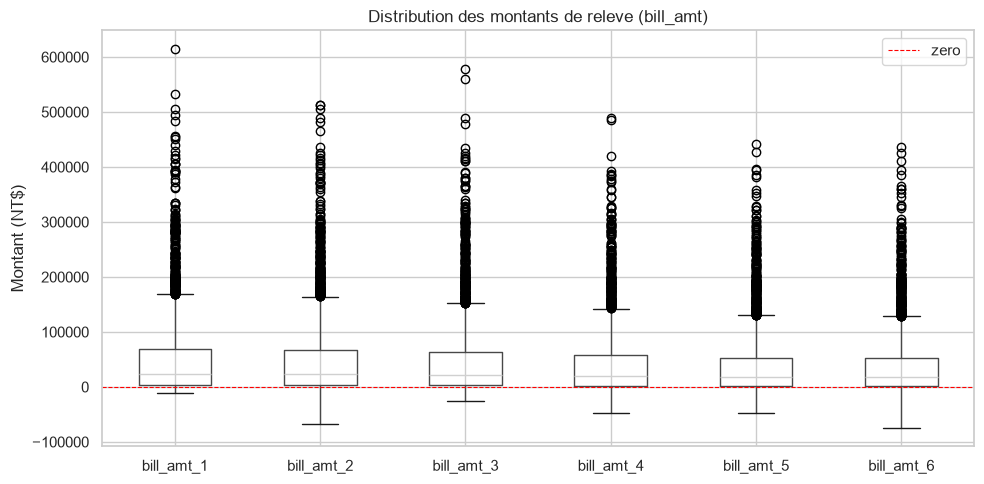

In [ ]:
# df.dedisplay(df.describe())

print("education_level hors plage :")
print(df["education_level"].value_counts().sort_index())

# Valeurs hors plage pour marital_status (attendu : 1 a 3)
print("\nmarital_status hors plage :")
print(df["marital_status"].value_counts().sort_index())

# Montants de releve negatifs
nb_bill_negatifs = (df[[c for c in df.columns if c.startswith("bill_amt")]] < 0).sum()
print("\nMontants releve negatifs par colonne :")
print(nb_bill_negatifs)

# bill_amt : boxplot pour visualiser les distributions et valeurs negatives
bill_cols = [c for c in df.columns if c.startswith("bill_amt")]

fig, ax = plt.subplots(figsize=(10, 5))
df[bill_cols].boxplot(ax=ax)
ax.set_title("Distribution des montants de releve (bill_amt)")
ax.set_ylabel("Montant (NT$)")
ax.axhline(0, color="red", linestyle="--", linewidth=0.8, label="zero")
ax.legend()
plt.tight_layout()
plt.show()scribe() pour avoir une vue d'ensemble des stats.



**Observations controle qualite :**
- Aucune valeur manquante, aucun doublon.
- `education_level` : valeurs 0, 5, 6 hors plage documentee (1-4). A recoder en 4 (autres) dans le pipeline etape 2.
- `marital_status` : valeur 0 hors plage documentee (1-3). A recoder en 3 (autres) dans le pipeline etape 2.
- `bill_amt_*` : ~60 valeurs negatives par colonne = avoirs client. Comportement normal, pas d'erreur.
- `pay_1` absent du dataset (passage direct de pay_0 a pay_2) : particularite du dataset source.

## 5. Exploration de la cible

### 5.1 Taux de defaut global

Taux de defaut global : 21.4%


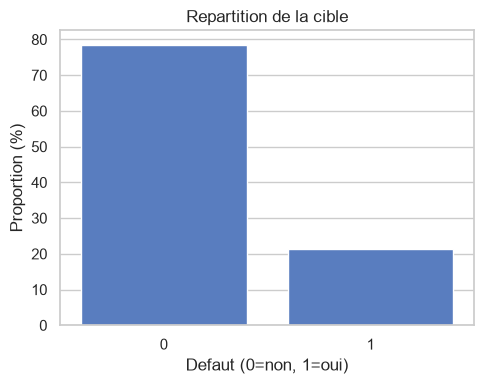

In [31]:
TARGET = "default_payment_next_month"
taux_defaut_global = df[TARGET].mean()
print(f"Taux de defaut global : {taux_defaut_global:.1%}")

target_dist = (
    df[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
    .set_axis(["defaut", "proportion"], axis=1)
)

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(data=target_dist, x="defaut", y="proportion", ax=ax)
ax.set_title("Repartition de la cible")
ax.set_xlabel("Defaut (0=non, 1=oui)")
ax.set_ylabel("Proportion (%)")
plt.tight_layout()
plt.show()


### 5.2 Taux de defaut par segment

Variables a explorer : `sex`, `education_level`, `marital_status`, et tranches d'age.

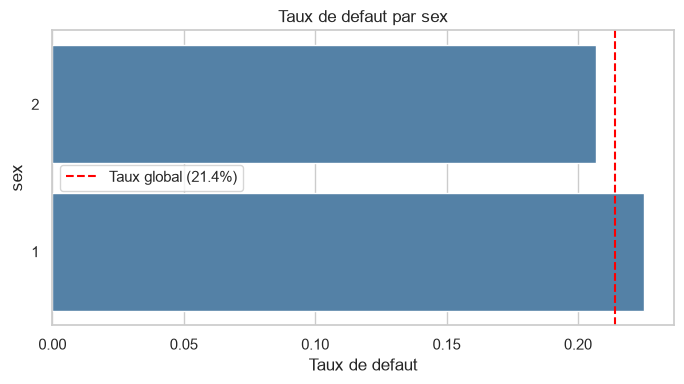

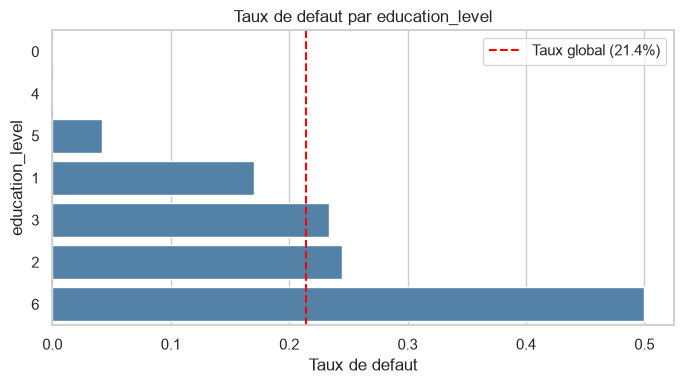

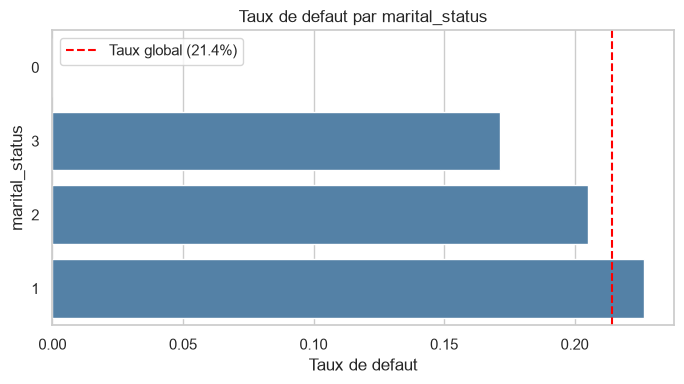

In [32]:
seg_cols = ["sex", "education_level", "marital_status"]

for col in seg_cols:
    df_cross = (
        pd.crosstab(index=df[col], columns=df[TARGET], normalize="index")
        .sort_values(1)
    )

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(x=df_cross[1], y=df_cross.index.astype(str), ax=ax, color="steelblue")
    ax.axvline(taux_defaut_global, color="red", linestyle="--", label=f"Taux global ({taux_defaut_global:.1%})")
    ax.set_title(f"Taux de defaut par {col}")
    ax.set_xlabel("Taux de defaut")
    ax.legend()
    plt.tight_layout()
    plt.show()
    

### Observations — Taux de défaut par segment

**sex** : Peu de différence entre hommes (1) et femmes (2), les deux proches du taux global.
Pas un facteur discriminant fort.

**education_level** :
- 6 (hors plage documentée) affiche un taux ~50% — à recoder, trop peu d'observations.
- 1 (3e cycle) a le taux le plus bas (~14%) : les plus diplômés défaillent moins.
- 2 (université) et 3 (lycée) sont au-dessus du taux global.

**marital_status** :
- Code 0 (hors plage) : aucune barre visible — 4 observations seulement, non représentatif.
- Les mariés (1) ont le taux de défaut le plus élevé.
- Les célibataires (2) sont légèrement en dessous du taux global.

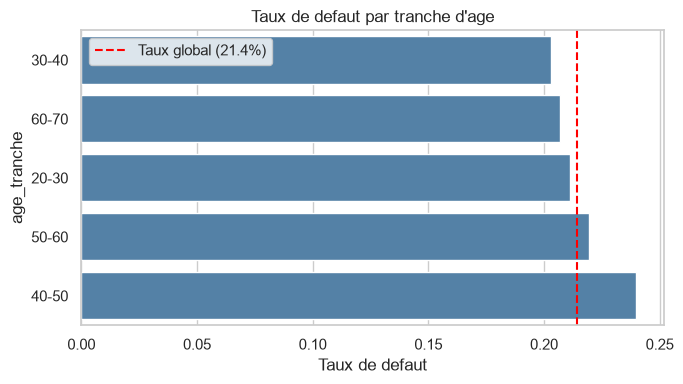

In [33]:
df["age_tranche"] = pd.cut(df["age"], bins=[20, 30, 40, 50, 60, 70], labels=["20-30", "30-40", "40-50", "50-60", "60-70"])

df_cross_age = (
    pd.crosstab(index=df["age_tranche"], columns=df[TARGET], normalize="index")
    .sort_values(1)
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=df_cross_age[1], y=df_cross_age.index.astype(str), ax=ax, color="steelblue")
ax.axvline(taux_defaut_global, color="red", linestyle="--", label=f"Taux global ({taux_defaut_global:.1%})")
ax.set_title("Taux de defaut par tranche d'age")
ax.set_xlabel("Taux de defaut")
ax.legend()
plt.tight_layout()
plt.show()

df = df.drop(columns=["age_tranche"])

**age** : Faible variation entre les tranches.
- 40-50 ans légèrement au-dessus du taux global (~24%).
- 30-40 et 60-70 légèrement en dessous.
- L'âge ne semble pas être un facteur discriminant fort dans ce dataset.

## 6. Protocole d'evaluation

Cette section **ne contient pas de code** mais tes decisions ecrites.  


### 6.1 Split train / test

### 6.1 Split train / validation / test

Split en 3 parties stratifiées (stratify=y) pour conserver le taux de défaut (~21%) dans chaque ensemble :
- **Train** : 72% (~2135 lignes) — entrainement du modele
- **Test** : 18% (~534 lignes) — evaluation finale, touche une seule fois
- **Validation** : 10% (~297 lignes) — reglage des hyperparametres

### 6.2 Metriques retenues

### 6.2 Métriques retenues

- **PR-AUC** (prioritaire) — plus adaptée que la ROC-AUC en cas de déséquilibre de classes
- **Recall@topK** — logique métier : parmi les K% clients les plus risqués, combien sont de vrais défauts ?
- Matrice de confusion — pour visualiser faux positifs / faux négatifs
- Precision / Recall / F1 au seuil retenu

**Metrique exclue** : accuracy — trompeuse à 21.4% de défaut (un modele qui predit toujours 0 aurait 78.6% d'accuracy).

### 6.3 Hypothese sur la gestion du desequilibre

 ### 6.3 Hypothese sur la gestion du desequilibre

Desequilibre modere (~21.4% de defaut). Approche retenue : class_weight="balanced" 
sur les modeles sklearn (LogisticRegression, HistGradientBoosting).
Cela ajuste automatiquement les poids des classes sans modifier le dataset.

A valider a l'etape 2 en comparant les PR-AUC avec et sans ce parametre.